In [57]:
#1.import the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Split data into training and testing sets 
from sklearn.model_selection import train_test_split 
# Logistic Regression classification model 
from sklearn.linear_model import LogisticRegression 
# Model evaluation metrics 
from sklearn.metrics import ( 
    accuracy_score,    
    precision_score,    
    recall_score,    
    f1_score,    
    confusion_matrix,   
    classification_report 
    )

In [3]:
#2. Load the dataset
df = pd.read_csv(r"C:\Users\LUKESH\OneDrive\Desktop\Telecom-Customer-Churn-Analysis\data\cleaned\Telco-Customer-Churn-Cleaned.csv")
print(df.head())

   customerID  gender SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female            No     Yes         No       1           No   
1  5575-GNVDE    Male            No      No         No      34          Yes   
2  3668-QPYBK    Male            No      No         No       2          Yes   
3  7795-CFOCW    Male            No      No         No      45           No   
4  9237-HQITU  Female            No      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... StreamingMovies  \
0  No phone service             DSL             No  ...              No   
1                No             DSL            Yes  ...              No   
2                No             DSL            Yes  ...              No   
3  No phone service             DSL            Yes  ...              No   
4                No     Fiber optic             No  ...              No   

         Contract PaperlessBilling              PaymentMethod MonthlyCharg

In [4]:
#3. Understand the Dataset 
# Number of rows and columns 
print("Dataset Shape:", df.shape) 

# Column names, data types and non-null counts 
df.info() 

# All column names 
print(df.columns)

Dataset Shape: (7043, 24)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customerID           7043 non-null   str    
 1   gender               7043 non-null   str    
 2   SeniorCitizen        7043 non-null   str    
 3   Partner              7043 non-null   str    
 4   Dependents           7043 non-null   str    
 5   tenure               7043 non-null   int64  
 6   PhoneService         7043 non-null   str    
 7   MultipleLines        7043 non-null   str    
 8   InternetService      7043 non-null   str    
 9   OnlineSecurity       7043 non-null   str    
 10  OnlineBackup         7043 non-null   str    
 11  DeviceProtection     7043 non-null   str    
 12  TechSupport          7043 non-null   str    
 13  StreamingTV          7043 non-null   str    
 14  StreamingMovies      7043 non-null   str    
 15  Contract             70

In [5]:
#4. Check Missing Values

# Count missing values in each column 
missing_values = df.isnull().sum() 
print(missing_values) 

# Show only columns with missing values 
print(missing_values[missing_values > 0])

customerID             0
gender                 0
SeniorCitizen          0
Partner                0
Dependents             0
tenure                 0
PhoneService           0
MultipleLines          0
InternetService        0
OnlineSecurity         0
OnlineBackup           0
DeviceProtection       0
TechSupport            0
StreamingTV            0
StreamingMovies        0
Contract               0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges         0
TotalCharges           0
Churn                  0
ChurnFlag              0
TenureGroup            0
MonthlyChargesGroup    0
dtype: int64
Series([], dtype: int64)


In [6]:
#5. Check Churn Target

# Count stayed and churned customers 
print(df["ChurnFlag"].value_counts()) 

# Calculate churn percentages 
churn_percentage = df["ChurnFlag"].value_counts(normalize=True) * 100 
print(churn_percentage)

ChurnFlag
0    5174
1    1869
Name: count, dtype: int64
ChurnFlag
0    73.463013
1    26.536987
Name: proportion, dtype: float64


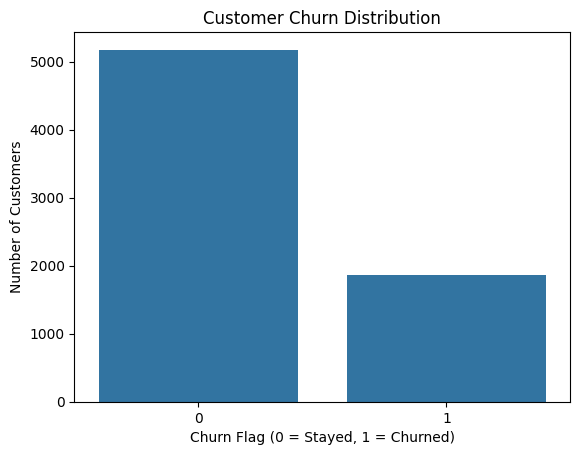

In [7]:
#6. Churn Distribution Chart
# Plot the number of stayed/churned customers
sns.countplot(x="ChurnFlag", data=df) 
plt.title("Customer Churn Distribution") 
plt.xlabel("Churn Flag (0 = Stayed, 1 = Churned)") 
plt.ylabel("Number of Customers")
plt.show()

In [8]:
#7. Remove Unnecessary Columns
# customerID is only an identifier, so remove it 
df = df.drop("customerID", axis=1)

# Remove grouped columns because original numerical values 
# tenure and MonthlyCharges are already available
df = df.drop(["TenureGroup", "MonthlyChargesGroup"], axis=1 )

In [9]:
#8. Handle Missing Values
# Check missing values 
print(df.isnull().sum())

# Remove rows containing missing values 
df = df.dropna() 

# Confirm total missing values 
print("Total missing values:", df.isnull().sum().sum())

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
ChurnFlag           0
dtype: int64
Total missing values: 0


In [10]:
# 9. Create X and y
# X = input features used by the model 
# ChurnFlag is removed because it is the target 
X = df.drop("ChurnFlag", axis=1) 

# y = target the model will predict # 0 = Stayed, 1 = Churned 
y = df["ChurnFlag"] 
print("Features:") 
print(X.columns) 
print("\nTarget:") 
print(y.name)

Features:
Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

Target:
ChurnFlag


In [11]:
# 10. Identify Column Types
# Find numerical columns 
numerical_cols = X.select_dtypes(include=["int64", "float64"] ).columns 

# Find text/categorical columns 
categorical_cols = X.select_dtypes(include=["object", "str"] ).columns 
print("Numerical Columns:") 
print(numerical_cols) 
print("\nCategorical Columns:") 
print(categorical_cols)

Numerical Columns:
Index(['tenure', 'MonthlyCharges', 'TotalCharges'], dtype='str')

Categorical Columns:
Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='str')


In [12]:
# 11. One-Hot Encoding
# Convert categorical text columns into 0/1 columns. 
# Example: Contract categories become separate columns. 
# drop_first=True removes one category to avoid redundancy. 

X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

In [13]:
# 12. Make Encoded Values Numeric
# Convert True/False values into 1/0 
X_encoded = X_encoded.astype(int) 

# Inspect the encoded data 
print(X_encoded.head()) 
print(X_encoded.dtypes)

   tenure  MonthlyCharges  TotalCharges  gender_Male  SeniorCitizen_Yes  \
0       1              29            29            0                  0   
1      34              56          1889            1                  0   
2       2              53           108            1                  0   
3      45              42          1840            1                  0   
4       2              70           151            0                  0   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0            1               0                 0   
1            0               0                 1   
2            0               0                 1   
3            0               0                 0   
4            0               0                 1   

   MultipleLines_No phone service  MultipleLines_Yes  ...  StreamingTV_Yes  \
0                               1                  0  ...                0   
1                               0                  0  ...                0   
2 

In [14]:
# 13. Final Data Check

# Check feature and target sizes 
print("X_encoded shape:", X_encoded.shape) 
print("y shape:", y.shape)

# Check total missing values 
print("Missing values:", X_encoded.isnull().sum().sum())

X_encoded shape: (7043, 31)
y shape: (7043,)
Missing values: 0


In [15]:
# 14. Train/Test Split 
# # 80% is used to train the model. 
# # 20% is kept unseen for testing. 
# stratify=y keeps the churn ratio similar in both sets. 
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, 
    y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y 
)

In [16]:
# 15. Check Split Size 
# Display the number of rows/columns in each split 
print("X_train:", X_train.shape) 
print("X_test:", X_test.shape) 
print("y_train:", y_train.shape) 
print("y_test:", y_test.shape)

X_train: (5634, 31)
X_test: (1409, 31)
y_train: (5634,)
y_test: (1409,)


In [17]:
# 16. Check Churn Distribution 
# Check churn percentages in training data 
print("Training Churn Distribution:") 
print(y_train.value_counts(normalize=True) * 100) 

# Check churn percentages in testing data 
print("\nTesting Churn Distribution:") 
print(y_test.value_counts(normalize=True) * 100)

Training Churn Distribution:
ChurnFlag
0    73.464679
1    26.535321
Name: proportion, dtype: float64

Testing Churn Distribution:
ChurnFlag
0    73.456352
1    26.543648
Name: proportion, dtype: float64


In [18]:
# 17. Create Logistic Regression Model 
# Logistic Regression is suitable for binary classification: # 0 = Stayed, 1 = Churned. 
# max_iter gives the model enough iterations to converge. 

model = LogisticRegression(max_iter=1000)

In [19]:
# 18. Train the Model 
# Teach the model using training features and known churn results 

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [20]:
# 19. Predict Churn 
# Predict 0/1 churn outcomes for unseen test customers 
y_pred = model.predict(X_test) 

# Show the first 20 predictions 
print(y_pred[:20])

[0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0]


In [21]:
# 20. Compare Actual vs Predicted 
# Create a simple comparison table 
comparison = pd.DataFrame({"Actual": y_test.values, "Predicted": y_pred }) 
print(comparison.head(20))

    Actual  Predicted
0        0          0
1        0          0
2        0          0
3        0          0
4        0          0
5        0          0
6        0          0
7        0          0
8        0          0
9        1          1
10       0          0
11       0          0
12       0          0
13       1          1
14       0          0
15       0          0
16       0          0
17       0          0
18       0          0
19       0          0


In [22]:
# 21. Accuracy 
# Percentage of all predictions that were correct 
accuracy = accuracy_score(y_test, y_pred) 
print("Accuracy:", accuracy) 
print("Accuracy %:", accuracy * 100)

Accuracy: 1.0
Accuracy %: 100.0


In [23]:
# 22. Precision 
# Among customers predicted as churners, 
# how many actually churned? 
precision = precision_score(y_test, y_pred) 
print("Precision:", precision) 
print("Precision %:", precision * 100)

Precision: 1.0
Precision %: 100.0


In [24]:
# 23. Recall
# Among customers who actually churned, 
# how many did the model successfully identify? 
recall = recall_score(y_test, y_pred) 
print("Recall:", recall) 
print("Recall %:", recall * 100)

Recall: 1.0
Recall %: 100.0


In [25]:
# 24. F1 Score 
# F1 balances precision and recall 
f1 = f1_score(y_test, y_pred) 
print("F1 Score:", f1)

F1 Score: 1.0


In [26]:
#25. Print All Metrics 
# Print the main evaluation metrics together 
print("===== MODEL PERFORMANCE =====") 
print("Accuracy :", round(accuracy * 100, 2), "%") 
print("Precision:", round(precision * 100, 2), "%") 
print("Recall   :", round(recall * 100, 2), "%") 
print("F1 Score :", round(f1 * 100, 2), "%")

===== MODEL PERFORMANCE =====
Accuracy : 100.0 %
Precision: 100.0 %
Recall   : 100.0 %
F1 Score : 100.0 %


In [27]:
#26. Classification Report 
# Detailed precision, recall and F1 score 
# for both classes: 0 (Stayed) and 1 (Churned) 

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1035
           1       1.00      1.00      1.00       374

    accuracy                           1.00      1409
   macro avg       1.00      1.00      1.00      1409
weighted avg       1.00      1.00      1.00      1409



In [28]:
# 27. Confusion Matrix 
# Create the confusion matrix 

cm = confusion_matrix(y_test, y_pred) 
print(cm)

[[1035    0]
 [   0  374]]


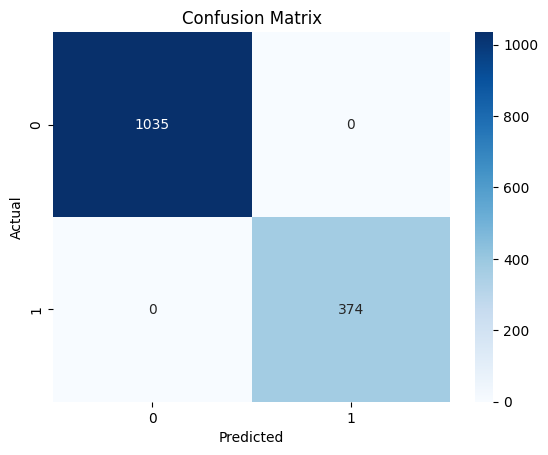

In [29]:
# 28. Confusion Matrix Visualization 
# Display the confusion matrix as a heatmap 

sns.heatmap(    
    cm,    
    annot=True,    
    fmt="d",    
    cmap="Blues" 
) 
plt.title("Confusion Matrix") 
plt.xlabel("Predicted") 
plt.ylabel("Actual") 
plt.show()

In [30]:
# 29. Logistic Regression Feature Coefficients 
# Get the coefficients learned by the model 
coefficients = model.coef_[0] 

# Pair each feature with its coefficient 
feature_importance = pd.DataFrame({"Feature": X_encoded.columns, "Coefficient": coefficients }) 

# Sort from most positive to most negative 
feature_importance = feature_importance.sort_values( by="Coefficient", ascending=False ) 

# Show the top positive associations 
print(feature_importance.head(10))

                                  Feature  Coefficient
30                              Churn_Yes    10.410549
28         PaymentMethod_Electronic check     0.261188
10            InternetService_Fiber optic     0.185238
9                       MultipleLines_Yes     0.111025
26                   PaperlessBilling_Yes     0.106030
8          MultipleLines_No phone service     0.092101
27  PaymentMethod_Credit card (automatic)     0.074569
23                    StreamingMovies_Yes     0.059859
21                        StreamingTV_Yes     0.059846
4                       SeniorCitizen_Yes     0.051932


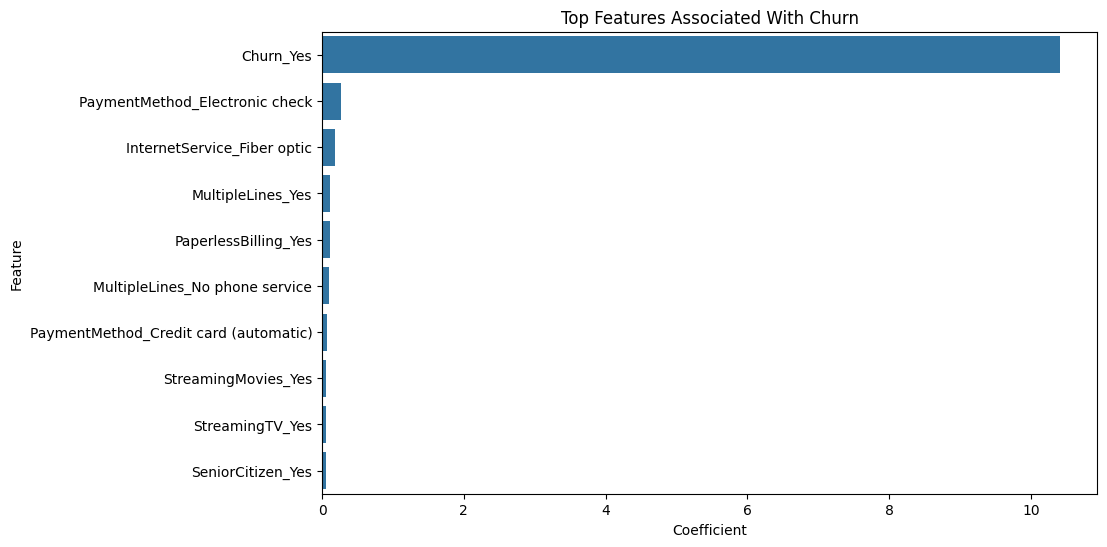

In [31]:
#30. Plot Top Features 
# Select the 10 most positive coefficients 
top_features = feature_importance.head(10) 
plt.figure(figsize=(10, 6)) 
sns.barplot(data=top_features,  x="Coefficient", y="Feature" ) 
plt.title("Top Features Associated With Churn")
plt.show()

In [32]:
#31. Calculate Churn Probability 
# predict_proba gives probabilities for both classes. 
# [:, 1] selects class 1, which means Churn. 
churn_probability = model.predict_proba(X_test)[:, 1] 
print(churn_probability[:10])

[1.39739099e-03 8.31936457e-03 1.68483793e-03 4.58495294e-03
 9.99853657e-04 6.76353128e-03 4.68716508e-03 2.06395465e-03
 4.06950507e-04 9.93284228e-01]


In [33]:
#32. Create Prediction Results 
# Store actual result, predicted result and probability 
prediction_results = pd.DataFrame({
    "Actual_Churn": y_test.values, 
    "Predicted_Churn": y_pred, 
    "Churn_Probability": churn_probability 
}) 
# Convert probability from 0-1 to percentage 
prediction_results["Churn_Probability"] = (prediction_results["Churn_Probability"] * 100)

In [34]:
#33. Create Business Risk Levels 
# Convert churn probability into simple business categories 
def risk_level(probability):
    # 70% or more = High Risk    
    if probability >= 70:        
        return "High Risk"    
    # 40% to below 70% = Medium Risk    
    elif probability >= 40:        
        return "Medium Risk"    
    # Below 40% = Low Risk    
    else:        
        return "Low Risk" 

    # Apply the function to every prediction 
prediction_results["Risk_Level"] =(prediction_results["Churn_Probability"].apply(risk_level))

In [35]:
#34. Find High-Risk Customers 
# Keep customers with at least 70% predicted churn probability 
high_risk_customers = prediction_results[prediction_results["Risk_Level"] == "High Risk"] 
print(high_risk_customers.head(20)) 
print("High-Risk Customers:", len(high_risk_customers))

    Actual_Churn  Predicted_Churn  Churn_Probability Risk_Level
9              1                1          99.328423  High Risk
13             1                1          99.619181  High Risk
20             1                1          99.625943  High Risk
26             1                1          99.542984  High Risk
27             1                1          99.645812  High Risk
29             1                1          99.707264  High Risk
34             1                1          99.714752  High Risk
36             1                1          99.312446  High Risk
38             1                1          99.684838  High Risk
39             1                1          98.909043  High Risk
45             1                1          99.518510  High Risk
49             1                1          99.318649  High Risk
51             1                1          99.652383  High Risk
55             1                1          99.511285  High Risk
61             1                1       

Risk_Level
Low Risk     1035
High Risk     374
Name: count, dtype: int64


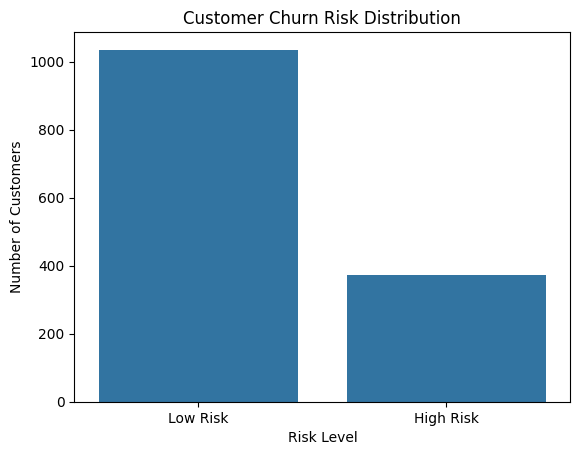

In [36]:
#35. Risk Distribution 
# Count customers in each risk category 
risk_counts = prediction_results["Risk_Level"].value_counts() 
print(risk_counts) 

# Visualize the risk categories 
sns.countplot(data=prediction_results, x="Risk_Level" ) 
plt.title("Customer Churn Risk Distribution") 
plt.xlabel("Risk Level") 
plt.ylabel("Number of Customers") 
plt.show()

In [37]:
#36. Save Predictions 
# Save the ML results so they can be used in Excel or Power BI 
prediction_results.to_csv("../data/churn_predictions.csv",index=False ) 
print("Prediction file saved successfully!")

Prediction file saved successfully!


In [38]:
#37. Final ML Summary
# Print a final summary of the model 
print("===================================") 
print(" CUSTOMER CHURN ML MODEL") 
print("===================================") 
print("Training Customers:", len(X_train)) 
print("Testing Customers:", len(X_test)) 
print("Accuracy :", round(accuracy * 100, 2), "%") 
print("Precision:", round(precision * 100, 2), "%") 
print("Recall   :", round(recall * 100, 2), "%") 
print("F1 Score :", round(f1 * 100, 2), "%") 
print("High-Risk Customers:", len(high_risk_customers)) 
print("===================================")

 CUSTOMER CHURN ML MODEL
Training Customers: 5634
Testing Customers: 1409
Accuracy : 100.0 %
Precision: 100.0 %
Recall   : 100.0 %
F1 Score : 100.0 %
High-Risk Customers: 374


In [39]:
# Check whether ChurnFlag accidentally exists in the features
print("Is ChurnFlag in X_encoded?")
print("ChurnFlag" in X_encoded.columns)

Is ChurnFlag in X_encoded?
False


In [40]:
print("Predictions equal actual:",
      (y_pred == y_test.values).all())

print("Incorrect predictions:",
      (y_pred != y_test.values).sum())

Predictions equal actual: True
Incorrect predictions: 0


In [41]:
# Check how strongly each feature is related to ChurnFlag
# A value extremely close to +1 or -1 is suspicious.

correlations = X_encoded.corrwith(y).sort_values(
    ascending=False
)

print(correlations)

Churn_Yes                                1.000000
InternetService_Fiber optic              0.308020
PaymentMethod_Electronic check           0.301919
MonthlyCharges                           0.193422
PaperlessBilling_Yes                     0.191825
SeniorCitizen_Yes                        0.150889
StreamingTV_Yes                          0.063228
StreamingMovies_Yes                      0.061382
MultipleLines_Yes                        0.040102
PhoneService_Yes                         0.011942
gender_Male                             -0.008612
MultipleLines_No phone service          -0.011942
DeviceProtection_Yes                    -0.066160
OnlineBackup_Yes                        -0.082255
PaymentMethod_Mailed check              -0.091683
PaymentMethod_Credit card (automatic)   -0.134302
Partner_Yes                             -0.150448
Dependents_Yes                          -0.164221
TechSupport_Yes                         -0.164674
OnlineSecurity_Yes                      -0.171226


In [42]:
# Show features with very strong correlation
print(
    correlations[
        (correlations > 0.8) |
        (correlations < -0.8)
    ]
)

Churn_Yes    1.0
dtype: float64


In [43]:
# Check each feature to see whether its values perfectly correspond to ChurnFlag.

for column in X_encoded.columns:

    table = pd.crosstab(
        X_encoded[column],
        y
    )

    print("\n-----------------------------")
    print(column)
    print(table)


-----------------------------
tenure
ChurnFlag    0    1
tenure             
0           11    0
1          233  380
2          115  123
3          106   94
4           93   83
...        ...  ...
68          91    9
69          87    8
70         108   11
71         164    6
72         356    6

[73 rows x 2 columns]

-----------------------------
MonthlyCharges
ChurnFlag         0   1
MonthlyCharges         
18               24   2
19              534  53
20              500  46
21               23   2
22                1   0
...             ...  ..
114              26   2
115              28   2
116              21   1
117               5   2
118               5   1

[99 rows x 2 columns]

-----------------------------
TotalCharges
ChurnFlag      0   1
TotalCharges        
0             11   0
18             3   1
19            52  25
20            46  30
21             2   1
...           ..  ..
8564           1   0
8594           1   0
8670           1   0
8672           1   0
86

In [44]:
# Find features that perfectly separate ChurnFlag
for column in X_encoded.columns:

    table = pd.crosstab(X_encoded[column], y)

    # Check whether every value of this feature
    # belongs to only one churn class
    if (table > 0).sum(axis=1).max() == 1:
        print("Possible leakage:", column)

Possible leakage: Churn_Yes


In [45]:
print(df.columns.tolist())

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'ChurnFlag']


In [46]:
# Remove the original Churn column
# because ChurnFlag is already our target
df = df.drop("Churn", axis=1)

In [47]:
# X contains only information available BEFORE knowing whether
# the customer churned
X = df.drop("ChurnFlag", axis=1)

# y is our target
# 0 = Stayed
# 1 = Churned
y = df["ChurnFlag"]

In [48]:
# Find categorical/text columns
categorical_cols = X.select_dtypes(
    include=["object", "str"]
).columns

print("Categorical columns:")
print(categorical_cols)

Categorical columns:
Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod'],
      dtype='str')


In [49]:
# Convert categorical columns into numerical columns
X_encoded = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)

# Convert True/False to 1/0
X_encoded = X_encoded.astype(int)

In [50]:
print("Churn_Yes" in X_encoded.columns)
print("Churn_No" in X_encoded.columns)
print("ChurnFlag" in X_encoded.columns)

False
False
False


In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [52]:
from sklearn.linear_model import LogisticRegression

# Create a fresh model
model = LogisticRegression(max_iter=1000)

# Train using the corrected data
model.fit(X_train, y_train)

c:\Users\LUKESH\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [53]:
# Predict churn for the unseen test data
y_pred = model.predict(X_test)

In [54]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("===================================")
print(" CORRECTED CUSTOMER CHURN ML MODEL")
print("===================================")

print("Accuracy :", round(accuracy * 100, 2), "%")
print("Precision:", round(precision * 100, 2), "%")
print("Recall   :", round(recall * 100, 2), "%")
print("F1 Score :", round(f1 * 100, 2), "%")

 CORRECTED CUSTOMER CHURN ML MODEL
Accuracy : 80.48 %
Precision: 65.52 %
Recall   : 55.88 %
F1 Score : 60.32 %


In [55]:
from sklearn.metrics import confusion_matrix

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[925 110]
 [165 209]]


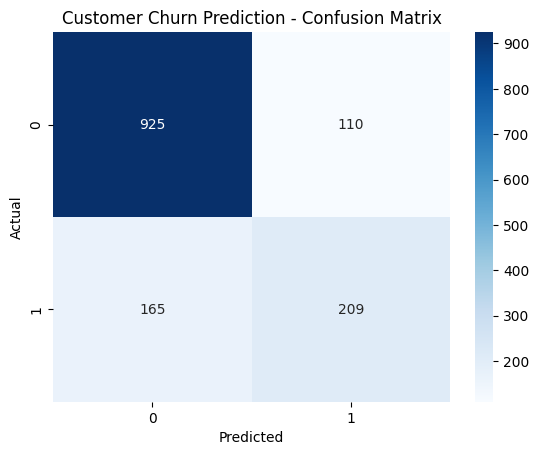

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create confusion matrix heatmap
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Customer Churn Prediction - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()